# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Liliana Rosales Gomez \
**Matricula:** 230370 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #0A4D8C 0%, #052C65 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #D6EAF8; font-size: 1.1em; margin-top: 10px;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s2) |Apliacion de metodos basicos de limpieza (eliminacion de duplicados,agrupacion y datos nulos) |

## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [1]:
# =========================================================
# SECTION 1 -Setup & Data Loading
# =========================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

print(f"✅ NumPy:      {np.__version__}")
print(f"✅ Pandas:     {pd.__version__}")
print('✅ Todas las librerias cargaron con exito')

✅ NumPy:      2.3.5
✅ Pandas:     2.3.3
✅ Todas las librerias cargaron con exito


In [2]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1447, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame. <a id='s2'></a>

In [4]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 33%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 92%
img_source           | URLs de Imágenes del Producto                 | missing: 0%
description          | Descripción detallada y completa (mayoría faltante) | missing: 92%
specifi

## 3. Limpieza de datos <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,101 / 1,447 products
✓ Duplicate ASINs: 9
✓ Availability categories: {'In Stock': 610, 'Unknown': 479, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 117, 'Ships 2+ weeks': 80, 'Other': 24, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


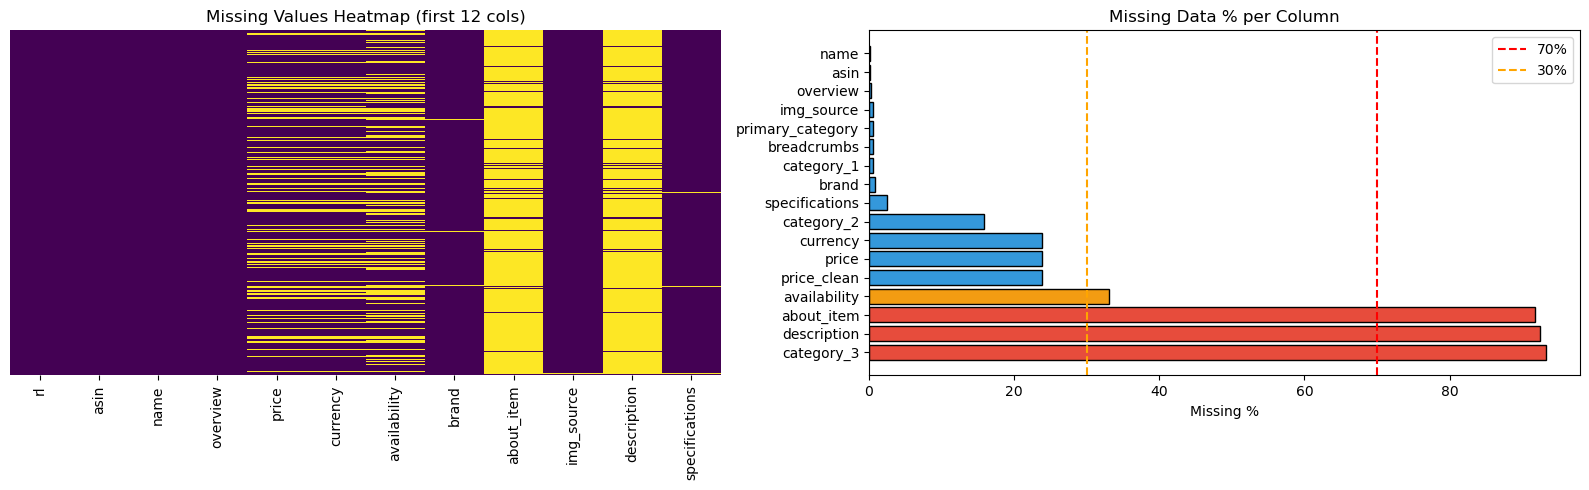

                  Missing Count  Missing Pct
category_3                 1350         93.3
description                1338         92.5
about_item                 1327         91.7
availability                479         33.1
price_clean                 346         23.9
price                       345         23.8
currency                    345         23.8
category_2                  228         15.8
specifications               36          2.5
brand                        11          0.8
category_1                    7          0.5
breadcrumbs                   7          0.5
primary_category              7          0.5
img_source                    7          0.5
overview                      4          0.3
asin                          1          0.1
name                          2          0.1


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Ejemplo cotidiano:</b><br>
Un agente inmobiliario no solo utiliza los metros cuadradod brutos, sino tambien considera la ubicaciónm la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos la informacion más valiosa del txto sin procesar categorias
</div>